##Intelligent Plant Monitoring and Care Using AI and IoT Integration
####Alaa H - Amro - Layan - Maha

##Import Libraries

In [ ]:
# Cell 1:

# Import required libraries
import os
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Load Dataset

In [ ]:
# Cell 2:

# Load dataset (adjust path if needed)
df = pd.read_csv('/content/drive/MyDrive/ECE333 labs/Crop_recommendationV2.csv')

# Preview first few rows
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


##Preprocessing

In [ ]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns)

Dataset shape: (2200, 23)
Columns: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency'],
      dtype='object')


In [ ]:
cols = ['label'] + [col for col in df.columns if col != 'label']
df = df[cols]

In [ ]:
df['label'] = df['label'].astype(str).str.strip().str.lower()

from sklearn.preprocessing import LabelEncoder

crop_le = LabelEncoder()
df['crop_id'] = crop_le.fit_transform(df['label'])


In [ ]:
df.dtypes

,0
label,object
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
soil_moisture,float64
soil_type,int64


In [ ]:
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 label                     0
N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
crop_id                   0
dtype: int64


#Load Crop Metadata (with Growing Notes)

In [ ]:
# ============================================
# Cell 3: Load Crop Metadata (with Growing Notes)
# ============================================

# Load metadata file you uploaded
meta = pd.read_csv("/content/drive/MyDrive/ECE333 labs/plant_metadata_detailed_numeric.csv")
meta.head()


,Crop Label,Scientific Name,Temperature Min (°C),Temperature Max (°C),Temperature Optimal,Humidity Range,pH Range,pH Optimal,Rainfall (mm),Nitrogen (kg/ha),Phosphorus (kg/ha),Potassium (kg/ha),Growing Notes
0,rice,Oryza sativa L.,20,32,21-30,70-90,5.0-7.9,5.0-6.5,1000-4500,60-200,40-80,40-110,"Tropical/subtropical crop, requires hot and hu..."
1,maize,Zea mays L.,18,30,22-26,60-70,5.0-7.5,6.0-7.0,60-100,77-190,40-90,40-135,Poor tolerance of acidic soils (<pH 5.0). N re...
2,chickpea,Cicer arietinum L.,10,30,18-29,40-60,6.0-8.6,6.0-7.5,600-1000,15-30,40-60,17-30,Cool-season legume. Fixes own nitrogen. Requir...
3,kidneybeans,Phaseolus vulgaris L.,15,32,20-28,50-70,5.0-6.5,5.8-6.5,700-900,20-30,60-70,20-30,Warm season crop. Well-drained soils. Sensitiv...
4,lentil,Lens culinaris Medik.,18,30,18-30,60-70,6.0-8.0,6.0-7.5,250-400,18-40,40-60,20-30,Cool-season legume. Drought-tolerant. Requires...


##Preprocessing

In [ ]:
print("Metadata shape:", meta.shape)
print("Columns:", meta.columns)

Metadata shape: (22, 13)
Columns: Index(['Crop Label', 'Scientific Name', 'Temperature Min (°C)',
       'Temperature Max (°C)', 'Temperature Optimal', 'Humidity Range',
       'pH Range', 'pH Optimal', 'Rainfall (mm)', 'Nitrogen (kg/ha)',
       'Phosphorus (kg/ha)', 'Potassium (kg/ha)', 'Growing Notes'],
      dtype='object')


In [ ]:
meta.dtypes

,0
Crop Label,object
Scientific Name,object
Temperature Min (°C),int64
Temperature Max (°C),int64
Temperature Optimal,object
Humidity Range,object
pH Range,object
pH Optimal,object
Rainfall (mm),object
Nitrogen (kg/ha),object


A lot of columns were "object" because they were text ranges, so we parsed them into numeric values before merging

In [ ]:
# 1) Normalize label column and lowercase values so joins are safe
meta = meta.rename(columns={'Crop Label': 'label'})   # meta is your loaded plant metadata dataframe
meta['label'] = meta['label'].astype(str).str.strip().str.lower()

def parse_range_to_tuple(text):
    """Return (min, max, mean) from a text like '21-30', '21 to 30', '70–90%', etc."""
    if pd.isna(text):
        return (np.nan, np.nan, np.nan)
    s = str(text).strip()

    # Match two numbers separated by dash, 'to', or space
    m = re.search(r'(-?\d+(?:\.\d+)?)(?:\s*(?:–|-|to)\s*)(-?\d+(?:\.\d+)?)', s, flags=re.IGNORECASE)

    if m:
        lo = float(m.group(1))
        hi = float(m.group(2))
        return (lo, hi, (lo + hi) / 2.0)

    # fallback: single numeric value
    m2 = re.search(r'(-?\d+(?:\.\d+)?)', s)
    if m2:
        v = float(m2.group(1))
        return (v, v, v)

    return (np.nan, np.nan, np.nan)

# 3) Columns to parse (present in your table). We create *_min, *_max, *_mean for each
text_cols = {
    'Temperature Optimal': 'temperature_opt',
    'Humidity Range': 'humidity',
    'pH Range': 'ph_range',
    'pH Optimal': 'ph_opt',
    'Rainfall (mm)': 'rainfall',
    'Nitrogen (kg/ha)': 'nitrogen',
    'Phosphorus (kg/ha)': 'phosphorus',
    'Potassium (kg/ha)': 'potassium'
}

for src_col, short in text_cols.items():
    if src_col in meta.columns:
        mins, maxs, means = [], [], []
        for v in meta[src_col].astype(str).fillna(''):
            lo, hi, mean = parse_range_to_tuple(v)
            mins.append(lo); maxs.append(hi); means.append(mean)
        meta[f'{short}_min'] = mins
        meta[f'{short}_max'] = maxs
        meta[f'{short}_mean'] = means

# 4) Drop columns we won't join as numeric (long text) and old columns
drop_cols = ['Scientific Name', 'Temperature Optimal',
             'Temperature Min (°C)','Temperature Max (°C)',
             'Humidity Range', 'pH Range','pH Optimal', 'Rainfall (mm)',
             'Nitrogen (kg/ha)','Phosphorus (kg/ha)','Potassium (kg/ha)']
for c in drop_cols:
    if c in meta.columns:
        meta = meta.drop(columns=[c])

In [ ]:
print("Missing values per column:\n", meta.isna().sum())

Missing values per column:
 label                   0
Growing Notes           0
temperature_opt_min     0
temperature_opt_max     0
temperature_opt_mean    0
humidity_min            0
humidity_max            0
humidity_mean           0
ph_range_min            0
ph_range_max            0
ph_range_mean           0
ph_opt_min              0
ph_opt_max              0
ph_opt_mean             0
rainfall_min            0
rainfall_max            0
rainfall_mean           0
nitrogen_min            0
nitrogen_max            0
nitrogen_mean           0
phosphorus_min          0
phosphorus_max          0
phosphorus_mean         0
potassium_min           0
potassium_max           0
potassium_mean          0
dtype: int64


In [ ]:
meta.dtypes

,0
label,object
Growing Notes,object
temperature_opt_min,float64
temperature_opt_max,float64
temperature_opt_mean,float64
humidity_min,float64
humidity_max,float64
humidity_mean,float64
ph_range_min,float64
ph_range_max,float64


#Feature Extraction

## Optimal Range Feature Extraction

In [ ]:
# ============================================
# MERGE METADATA WITH MAIN DF
# ============================================

df = df.merge(
    meta[
        [
            "label",

            # Temperature
            "temperature_opt_min", "temperature_opt_max", "temperature_opt_mean",

            # Humidity
            "humidity_min", "humidity_max", "humidity_mean",

            # pH
            "ph_range_min", "ph_range_max", "ph_range_mean",
            "ph_opt_min", "ph_opt_max", "ph_opt_mean",

            # Rainfall
            "rainfall_min", "rainfall_max", "rainfall_mean",

            # Nitrogen
            "nitrogen_min", "nitrogen_max", "nitrogen_mean",

            # Phosphorus
            "phosphorus_min", "phosphorus_max", "phosphorus_mean",

            # Potassium
            "potassium_min", "potassium_max", "potassium_mean"
        ]
    ],
    left_on="label",
    right_on="label",
    how="left"
)

# ============================================
# CREATE DEVIATION FEATURES
# ============================================

# Temperature deviation
df["temp_deviation"] = df["temperature"] - df["temperature_opt_mean"]

# Humidity deviation
df["humidity_deviation"] = df["humidity"] - df["humidity_mean"]

# Rainfall deviation
df["rainfall_deviation"] = df["rainfall"] - df["rainfall_mean"]

# pH deviation (use optimal)
df["pH_deviation"] = df["ph"] - df["ph_opt_mean"]

# Nutrient deviations
df["N_deviation"] = df["N"] - df["nitrogen_mean"]
df["P_deviation"] = df["P"] - df["phosphorus_mean"]
df["K_deviation"] = df["K"] - df["potassium_mean"]

# Moisture deviation
df["moisture_deviation"] = df["soil_moisture"] - df["rainfall_mean"]

# Check everything
df.head()

,label,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,...,potassium_max,potassium_mean,temp_deviation,humidity_deviation,rainfall_deviation,pH_deviation,N_deviation,P_deviation,K_deviation,moisture_deviation
0,rice,90,42,43,20.879744,82.002744,6.502985,202.935536,29.446064,2,...,110.0,75.0,-4.620256,2.002744,-2547.064464,0.752985,-40.0,-18.0,-32.0,-2720.553936
1,rice,85,58,41,21.770462,80.319644,7.038096,226.655537,12.851183,3,...,110.0,75.0,-3.729538,0.319644,-2523.344463,1.288096,-45.0,-2.0,-34.0,-2737.148817
2,rice,60,55,44,23.004459,82.320763,7.840207,263.964248,29.363913,2,...,110.0,75.0,-2.495541,2.320763,-2486.035752,2.090207,-70.0,-5.0,-31.0,-2720.636087
3,rice,74,35,40,26.491096,80.158363,6.980401,242.864034,26.207732,3,...,110.0,75.0,0.991096,0.158363,-2507.135966,1.230401,-56.0,-25.0,-35.0,-2723.792268
4,rice,78,42,42,20.130175,81.604873,7.628473,262.717340,28.236236,2,...,110.0,75.0,-5.369825,1.604873,-2487.282660,1.878473,-52.0,-18.0,-33.0,-2721.763764


In [ ]:
# ============================================
# Cell 5: Feature Extraction from df (Numeric)
# ============================================

#temp mean
df['temp_mean'] = df['temperature'].rolling(window=5, min_periods=1).mean()

#temp variance
df['temp_var'] = df['temperature'].rolling(window=5, min_periods=1).var()

#humdity mean
df['humidity_mean_roll'] = df['humidity'].rolling(window=5, min_periods=1).mean()

#np ratio
df['np_ratio'] = df['N'] / (df['P'] + 1e-5)


df['nk_ratio'] = df['N'] / (df['K'] + 1e-5)

scaler = StandardScaler()
feature_cols = ['temperature','humidity','soil_moisture','ph',
                'N','P','K',
                'temp_mean','temp_var','humidity_mean_roll','np_ratio','nk_ratio']
X = scaler.fit_transform(df[feature_cols])
df[feature_cols].head()

,temperature,humidity,soil_moisture,ph,N,P,K,temp_mean,temp_var,humidity_mean_roll,np_ratio,nk_ratio
0,20.879744,82.002744,29.446064,6.502985,90,42,43,20.879744,NaN,82.002744,2.142857,2.093023
1,21.770462,80.319644,12.851183,7.038096,85,58,41,21.325103,0.396689,81.161194,1.465517,2.073170
2,23.004459,82.320763,29.363913,7.840207,60,55,44,21.884888,1.138424,81.547717,1.090909,1.363636
3,26.491096,80.158363,26.207732,6.980401,74,35,40,23.036440,6.063238,81.200378,2.114285,1.850000
4,20.130175,81.604873,28.236236,7.628473,78,42,42,22.455187,6.236704,81.281277,1.857142,1.857142


In [ ]:
# ============================================
# Cell 6: Feature Extraction (Growing Notes NLP)
# ============================================

def extract_notes_features(note):
    features = {
        "ColdTolerance": bool(re.search(r'cold|tolerates.*-?\d', note.lower())),
        "HeatTolerance": "high temp" in note.lower() or "hot" in note.lower(),
        "HumidityHigh": "high humidity" in note.lower() or "humid" in note.lower(),
        "HumidityLow": "low humidity" in note.lower(),
        "WaterloggingSensitive": "waterlogging" in note.lower() or "sensitive to waterlogging" in note.lower(),
        "NitrogenFixing": "fixes own nitrogen" in note.lower(),
        "FrostSensitive": "frost susceptible" in note.lower() or "sensitive to frost" in note.lower(),
        "ShadePreference": "shade" in note.lower(),
        "PhotoperiodSensitive": "photoperiod" in note.lower(),
        "RootSystemExtensive": "extensive root system" in note.lower(),
        "DormancyColdRequirement": "dormancy" in note.lower(),
    }
    return pd.Series(features)

# Apply to metadata
notes_features = meta['Growing Notes'].apply(extract_notes_features)
meta = pd.concat([meta, notes_features], axis=1)

# Merge the newly extracted NLP features from meta into df
# We only need the label and the NLP feature columns from meta for this merge
nlp_cols = notes_features.columns.tolist()
df = df.merge(meta[['label'] + nlp_cols], on='label', how='left')

meta[['label','ColdTolerance','HeatTolerance','HumidityHigh','HumidityLow',
      'WaterloggingSensitive','NitrogenFixing','FrostSensitive']].head()

,label,ColdTolerance,HeatTolerance,HumidityHigh,HumidityLow,WaterloggingSensitive,NitrogenFixing,FrostSensitive
0,rice,False,True,True,False,False,False,False
1,maize,False,False,False,False,False,False,False
2,chickpea,True,False,True,True,False,True,False
3,kidneybeans,False,False,False,False,True,False,True
4,lentil,True,False,False,False,False,False,False


In [ ]:
#GLOBAL CONSTANTS

RAINFALL_MIN_MEAN = df['rainfall_min'].mean()


#___________________________________________________________________________________________________________________

#Suitability Engine

In [ ]:
# ========================================
# SUITABILITY ENGINE (0–100%)
# ========================================

def target_soil_moisture(row):
    relative = row["rainfall_min"] / RAINFALL_MIN_MEAN
    base_low, base_high = 25, 45
    moisture_low = max(10, min(40, base_low * relative))
    moisture_high = max(30, min(70, base_high * relative))
    return moisture_low, moisture_high


def compute_suitability_row(row):
    score = 0
    total_weight = 0

    def add_score(val, low, high, weight):
        nonlocal score, total_weight
        total_weight += weight
        if low <= val <= high:
            score += weight
        else:
            deviation = min(abs(val - low), abs(val - high))
            max_dev = abs(high - low) / 2
            penalty = min(1, deviation / (max_dev + 1e-6))
            score += weight * (1 - penalty)

    # Temperature
    add_score(row['temperature'], row['temperature_opt_min'], row['temperature_opt_max'], 0.20)

    # Humidity
    add_score(row['humidity'], row['humidity_min'], row['humidity_max'], 0.15)

    # Soil Moisture
    moisture_low, moisture_high = target_soil_moisture(row)
    add_score(row['soil_moisture'], moisture_low, moisture_high, 0.20)

    # pH
    add_score(row['ph'], row['ph_opt_min'], row['ph_opt_max'], 0.20)

    # NPK
    add_score(row['N'], row['nitrogen_min'], row['nitrogen_max'], 0.10)
    add_score(row['P'], row['phosphorus_min'], row['phosphorus_max'], 0.10)
    add_score(row['K'], row['potassium_min'], row['potassium_max'], 0.05)

    return round((score / total_weight) * 100, 2)


###Suitability Label

In [ ]:
def suitability_label(score):
    if score >= 80: return "Highly suitable"
    if score >= 60: return "Suitable"
    if score >= 40: return "Moderate"
    if score >= 20: return "Low"
    return "Unsuitable"


df['suitability_score'] = df.apply(compute_suitability_row, axis=1)
df['suitability_label'] = df['suitability_score'].apply(suitability_label)

##Decision Making

In [ ]:
# ==========================================
# BLOCK 3 — RULE-BASED TEACHER (multi-label actions)
# ==========================================

def rule_based_actions(row):
    actions_list = []
    moisture_low, moisture_high = target_soil_moisture(row)

    # Irrigation decisions
    if row['soil_moisture'] < moisture_low:
        actions_list.append("Increase irrigation")
    if row['soil_moisture'] > moisture_high:
        actions_list.append("Reduce irrigation")

    # Temperature decisions
    if row['temperature'] < row['temperature_opt_min']:
        actions_list.append("Increase temperature")
    if row['temperature'] > row['temperature_opt_max']:
        actions_list.append("Activate cooling fan")

    # pH correction
    if row['ph'] < row['ph_opt_min']:
        actions_list.append("Increase pH")
    if row['ph'] > row['ph_opt_max']:
        actions_list.append("Decrease pH")

    # Fertilizer application
    if row['N'] < row['nitrogen_min']:
        actions_list.append("Add nitrogen fertilizer")
    if row['P'] < row['phosphorus_min']:
        actions_list.append("Add phosphorus fertilizer")
    if row['K'] < row['potassium_min']:
        actions_list.append("Add potassium fertilizer")

    # If no actions triggered, maintain conditions
    if not actions_list:
        actions_list.append("Maintain conditions")

    return actions_list

# Apply to dataframe
df["actions"] = df.apply(rule_based_actions, axis=1)


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

all_actions = [
    "Increase irrigation", "Reduce irrigation",
    "Increase temperature", "Activate cooling fan",
    "Increase pH", "Decrease pH",
    "Add nitrogen fertilizer", "Add phosphorus fertilizer", "Add potassium fertilizer",
    "Maintain conditions"
]

mlb = MultiLabelBinarizer(classes=all_actions)
y_multi = mlb.fit_transform(df["actions"])


In [ ]:
# ==========================================
# SUITABILITY GAIN MAPPING (Multi-label)
# ==========================================

GAIN_MAP = {
    "Increase irrigation": 12,
    "Reduce irrigation": 8,
    "Increase temperature": 9,
    "Activate cooling fan": 9,
    "Increase pH": 10,
    "Decrease pH": 10,
    "Add nitrogen fertilizer": 15,
    "Add phosphorus fertilizer": 14,
    "Add potassium fertilizer": 13,
    "Maintain conditions": 0
}

# Each row has a list of actions now (df["actions"])
df["suitability_gain"] = df["actions"].apply(
    lambda actions: sum(GAIN_MAP[a] for a in actions if a in GAIN_MAP)
)


Prepare ML Dataset for Decision Model

In [ ]:
decision_features = [
    # Raw data
    'temperature', 'humidity', 'soil_moisture', 'ph', 'N', 'P', 'K',

    # Rolling features
    'temp_mean', 'temp_var', 'humidity_mean_roll',
    'np_ratio', 'nk_ratio',

    # Min, Max, Mean for rules
    'temperature_opt_min', 'temperature_opt_max', 'temperature_opt_mean',
    'humidity_min', 'humidity_max', 'humidity_mean',
    'ph_opt_min', 'ph_opt_max', 'ph_opt_mean',
    'nitrogen_min', 'nitrogen_max', 'nitrogen_mean',
    'phosphorus_min', 'phosphorus_max', 'phosphorus_mean',
    'potassium_min', 'potassium_max', 'potassium_mean',

    # Deviations
    'temp_deviation', 'humidity_deviation', 'pH_deviation',
    'N_deviation', 'P_deviation', 'K_deviation',

    # NLP traits relevant to care
    'WaterloggingSensitive', 'NitrogenFixing',
    'HeatTolerance', 'ColdTolerance', 'FrostSensitive',
    'RootSystemExtensive'
]

decision_features = decision_features + ['crop_id']


In [ ]:
decision_features = [f for f in decision_features if f in df.columns]

# Keep rows where features and the multi-label actions list are not missing
dec_df = df.dropna(subset=decision_features + ['actions'])

In [ ]:
print(len(dec_df))

2199


Train Deep Learning Teacher Model

In [ ]:
# ==========================================
# TEACHER MODEL (Neural Network, Multi-label)
# Updated with separate validation split
# ==========================================

# Use the cleaned dataframe with multi-label actions
dec_df = df.dropna(subset=decision_features + ['actions'])

# Features and labels
X = dec_df[decision_features]
y_multi = mlb.transform(dec_df["actions"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# First split: Train (60%) and Temp (40%)
X_train, X_temp, y_train_multi, y_temp_multi = train_test_split(
    X_scaled, y_multi, test_size=0.4, random_state=42
)

# Second split: Validation (20%) and Test (20%)
X_val, X_test, y_val_multi, y_test_multi = train_test_split(
    X_temp, y_temp_multi, test_size=0.5, random_state=42
)

# Teacher model architecture
teacher_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(all_actions), activation='sigmoid')
])

from tensorflow.keras.metrics import Precision, Recall

teacher_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', Precision(name='precision'), Recall(name='recall')]
)

# Train teacher with dedicated validation set
history = teacher_model.fit(
    X_train,
    y_train_multi,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val_multi),
    verbose=1
)

# Teacher soft targets
teacher_probs = teacher_model.predict(X_train, verbose=0)
teacher_probs_val = teacher_model.predict(X_val, verbose=0)
teacher_probs_test = teacher_model.predict(X_test, verbose=0)



Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.7049 - loss: 0.5712 - precision: 0.5368 - recall: 0.5549 - val_binary_accuracy: 0.8564 - val_loss: 0.3409 - val_precision: 0.8634 - val_recall: 0.6276
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8756 - loss: 0.3035 - precision: 0.8844 - recall: 0.6827 - val_binary_accuracy: 0.9100 - val_loss: 0.2367 - val_precision: 0.9170 - val_recall: 0.7746
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9203 - loss: 0.2133 - precision: 0.9205 - recall: 0.8061 - val_binary_accuracy: 0.9275 - val_loss: 0.1845 - val_precision: 0.9202 - val_recall: 0.8343
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9379 - loss: 0.1678 - precision: 0.9328 - recall: 0.8575 - val_binary_accuracy: 0.9373 - val_loss: 0.1556 - val_precision: 0.9163 - val_recall: 0.8739
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9508 - loss: 0.1434 - precision: 0.9329 - recall: 0

In [ ]:
# ==========================================
# MODEL EVALUATION (Multi-label, Beautiful Table)
# ==========================================
from tabulate import tabulate
import pandas as pd
import numpy as np

print("\nTeacher Model Evaluation on Test Set")

# Evaluate teacher model
results = teacher_model.evaluate(X_test, y_test_multi, verbose=0)
metrics_names = teacher_model.metrics_names

# Build metrics table
metrics_table = [[name, f"{val:.4f}"] for name, val in zip(metrics_names, results)]
print(tabulate(metrics_table, headers=["Metric", "Value"], tablefmt="fancy_grid"))

# ==========================================
# SHOW SAMPLE PREDICTIONS (Multi-label, Beautiful Table)
# ==========================================

# Take 10 random predictions
indices = np.random.choice(len(X_test), size=10, replace=False)
sample_X = X_test[indices]
sample_true = y_test_multi[indices]

# Predict probabilities
pred_probs = teacher_model.predict(sample_X)

# Threshold predictions
threshold = 0.5
pred_actions = (pred_probs > threshold).astype(int)

# Build rows for table
rows = []
for i in range(len(indices)):
    true_actions = [all_actions[j] for j in range(len(all_actions)) if sample_true[i][j] == 1]
    predicted_actions = [all_actions[j] for j in range(len(all_actions)) if pred_actions[i][j] == 1]
    confidences = [f"{all_actions[j]} ({pred_probs[i][j]*100:.1f}%)" for j in range(len(all_actions)) if pred_actions[i][j] == 1]

    rows.append([
        indices[i],
        ", ".join(true_actions) if true_actions else "None",
        ", ".join(predicted_actions) if predicted_actions else "None",
        "; ".join(confidences) if confidences else "None"
    ])

# Print as a nice table
print("\nSample Predictions (Teacher Model):")
print(tabulate(rows, headers=["Row #", "True Actions", "Predicted Actions", "Confidences"], tablefmt="fancy_grid"))



Teacher Model Evaluation on Test Set
╒═════════════════╤═════════╕
│ Metric          │   Value │
╞═════════════════╪═════════╡
│ loss            │  0.0824 │
├─────────────────┼─────────┤
│ compile_metrics │  0.9607 │
╘═════════════════╧═════════╛
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Sample Predictions (Teacher Model):
╒═════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│   Row # │ True Actions                                                                                      │ Predicted Actions                                                                                 │ Confidences                                                                                                            

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Classification Report (Multi-label):
                           precision    recall  f1-score   support

      Increase irrigation       0.99      0.97      0.98       259
        Reduce irrigation       0.00      0.00      0.00         0
     Increase temperature       1.00      0.78      0.88       104
     Activate cooling fan       0.96      0.89      0.93        28
              Increase pH       0.94      0.97      0.95       118
              Decrease pH       0.94      0.97      0.96       101
  Add nitrogen fertilizer       0.96      0.96      0.96       255
Add phosphorus fertilizer       0.99      0.89      0.94       155
 Add potassium fertilizer       0.86      0.90      0.88       273
      Maintain conditions       1.00      0.13      0.24        15

                micro avg       0.95      0.92      0.93      1308
                macro avg       0.87      0.75      0.77      1308
             weighted avg       0.95      0.92   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

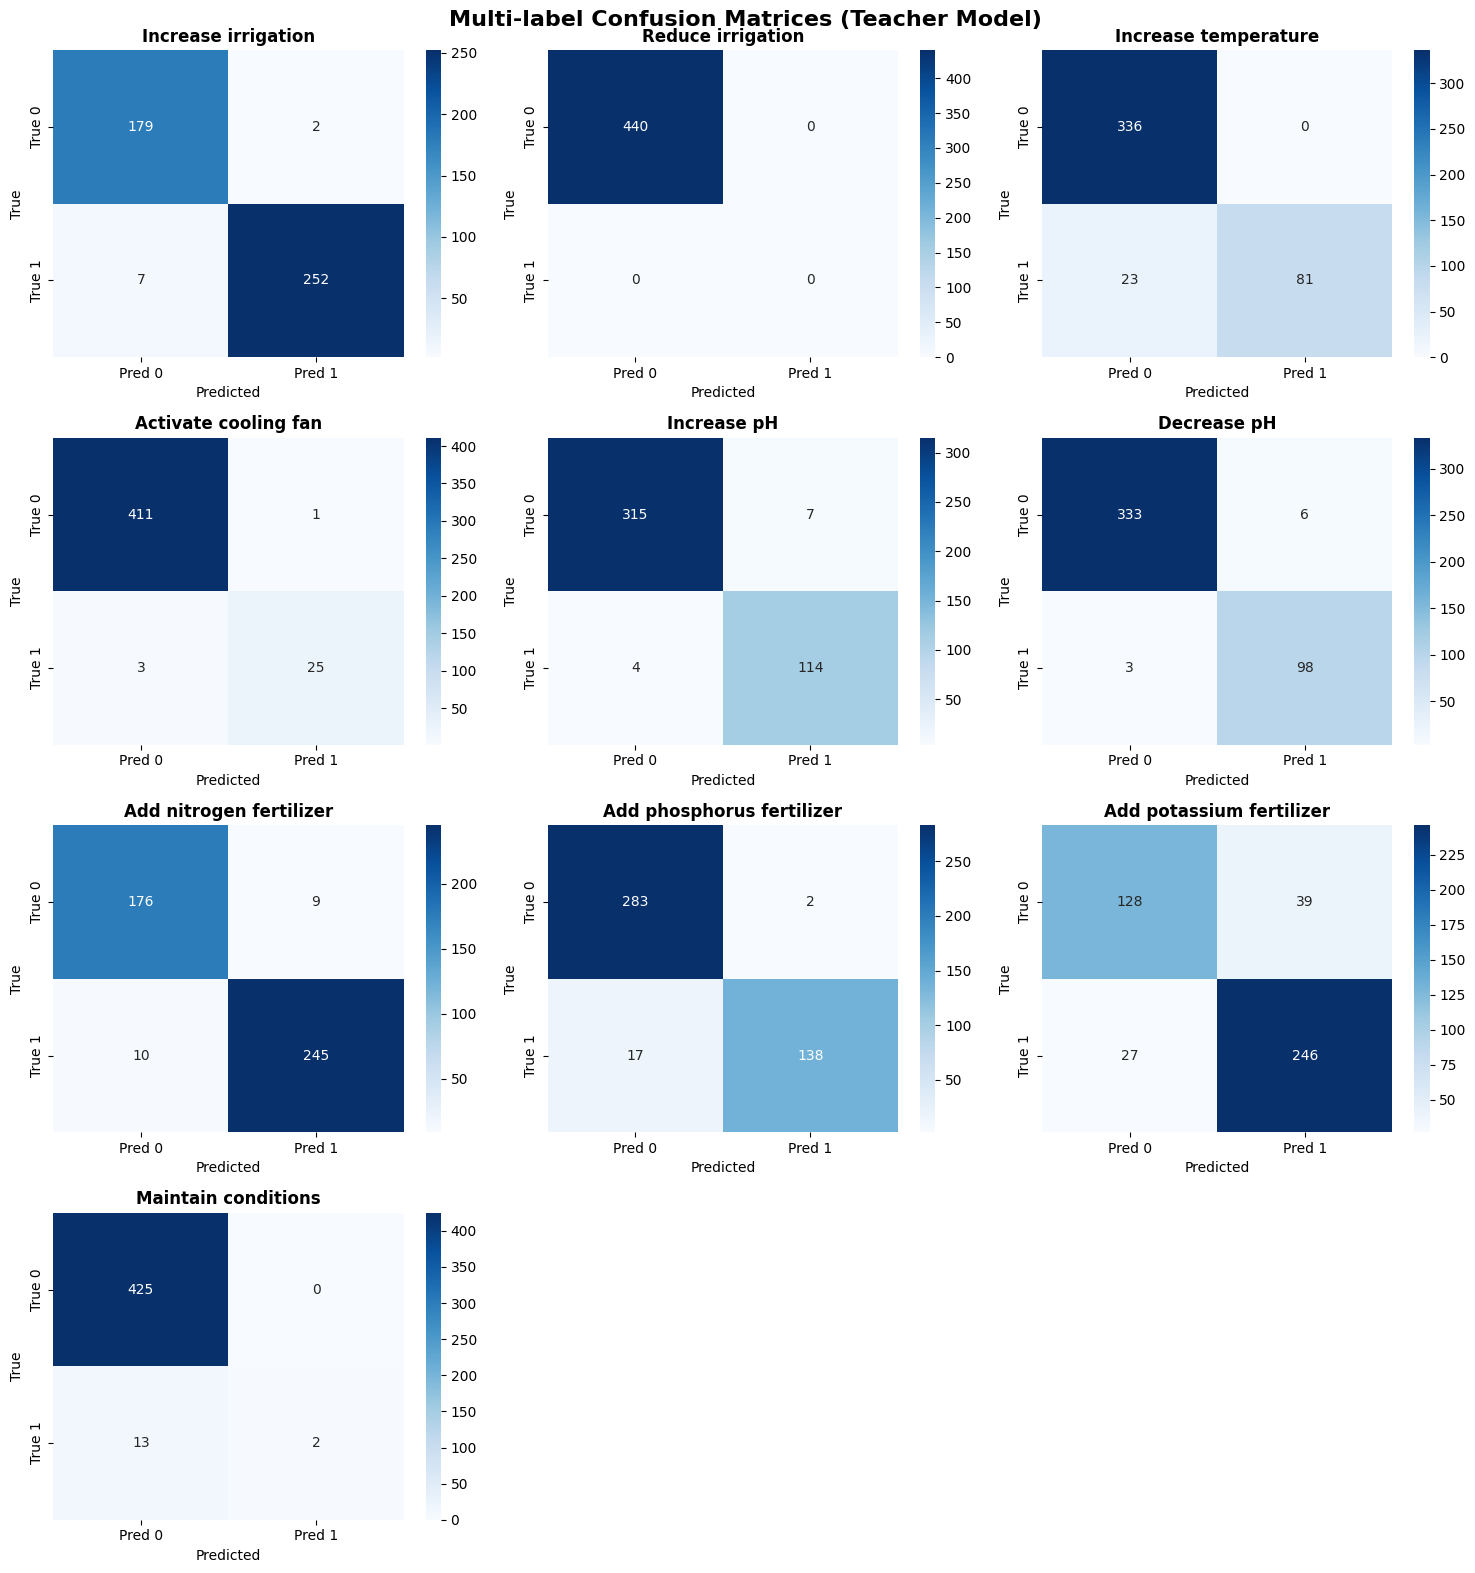

In [ ]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict and threshold
pred_probs = teacher_model.predict(X_test)
y_pred_multi = (pred_probs > 0.5).astype(int)

# Classification report
print("\nClassification Report (Multi-label):")
print(classification_report(y_test_multi, y_pred_multi, target_names=all_actions))

# Confusion matrices
cm = multilabel_confusion_matrix(y_test_multi, y_pred_multi)

# Auto-size grid
num_classes = len(cm)
cols = 3
rows = int(np.ceil(num_classes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.ravel()

for i in range(num_classes):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap="Blues", ax=axes[i],
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    axes[i].set_title(all_actions[i], fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

# Hide unused axes
for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Multi-label Confusion Matrices (Teacher Model)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Distilled Student Model (Edge/Raspberry Pi)

In [ ]:
# ==========================================
# STUDENT MODEL (Multi-label Distillation)
# ==========================================

T = 2.0   # temperature
alpha = 0.5  # blend weight between hard and soft targets

# Teacher soft targets for the whole training set
teacher_probs_train = teacher_model.predict(X_train, verbose=0)

# Apply temperature scaling
teacher_probs_train = tf.nn.softmax(tf.math.log(teacher_probs_train + 1e-8) / T).numpy()

# Custom distillation loss
def distillation_loss(y_true, y_pred):
    # y_true here is the batch-specific teacher probabilities
    y_true_soft = tf.nn.softmax(tf.math.log(y_true + 1e-8) / T)
    y_pred_soft = tf.nn.softmax(tf.math.log(y_pred + 1e-8) / T)
    return tf.keras.losses.KLDivergence()(y_true_soft, y_pred_soft) * (T * T)

# Student model (smaller, edge-friendly)
student_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(len(all_actions), activation='sigmoid')  # multi-label output
])

student_model.compile(optimizer='adam', loss=distillation_loss)

# Train student on teacher soft targets
student_history = student_model.fit(
    X_train,
    teacher_probs_train,   # teacher soft targets, batched automatically
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.9585 - val_loss: 1.5804
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4726 - val_loss: 1.2021
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1079 - val_loss: 0.8559
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7858 - val_loss: 0.5800
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5242 - val_loss: 0.4125
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4035 - val_loss: 0.3166
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3030 - val_loss: 0.2528
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2425 - val_loss: 0.2078
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2027 - val_loss: 0.1734
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1593 - val_loss: 0.1471
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1376 - val_loss: 0.1248
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1181 - val_

In [ ]:
student_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['binary_accuracy', Precision(name='precision'), Recall(name='recall')])
student_model.evaluate(X_test, y_test_multi, verbose=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9396 - loss: 0.1524 - precision: 0.9385 - recall: 0.8559  


[0.1542307585477829,
 0.9390908479690552,
 0.9355108737945557,
 0.8539755344390869]

In [ ]:
# ==========================================
# STUDENT MODEL RESULTS DISPLAY (Multi-label)
# ==========================================
!pip install colorama
import numpy as np
from tabulate import tabulate
from colorama import Fore, Style

# 1) Evaluate student on test set (against ground truth multi-labels)
student_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['binary_accuracy',
                               tf.keras.metrics.Precision(name='precision'),
                               tf.keras.metrics.Recall(name='recall')])

student_loss, student_acc, student_prec, student_rec = student_model.evaluate(X_test, y_test_multi, verbose=0)

print("\n📌 Student Model Evaluation Results")
print(f"Binary Accuracy: {student_acc:.4f} | Loss: {student_loss:.4f} | "
      f"Precision: {student_prec:.4f} | Recall: {student_rec:.4f}")

# 2) Generate sample predictions
indices = np.random.choice(len(X_test), size=10, replace=False)
sample_X = X_test[indices]
sample_true = y_test_multi[indices]

student_probs = student_model.predict(sample_X, verbose=0)

# Threshold predictions at 0.5
threshold = 0.5
student_pred = (student_probs > threshold).astype(int)

# 3) Build a clean table
table_data = []
for i in range(len(indices)):
    crop_name = crop_le.inverse_transform([dec_df.iloc[indices[i]]['crop_id']])[0]
    true_actions = [all_actions[j] for j in range(len(all_actions)) if sample_true[i][j] == 1]
    pred_actions = [all_actions[j] for j in range(len(all_actions)) if student_pred[i][j] == 1]
    confidences = [f"{all_actions[j]} ({student_probs[i][j]*100:.1f}%)" for j in range(len(all_actions)) if student_pred[i][j] == 1]

    # Highlight if prediction matches all true actions
    if set(true_actions) == set(pred_actions):
        pred_display = Fore.GREEN + ", ".join(pred_actions) + Style.RESET_ALL
    else:
        pred_display = Fore.RED + ", ".join(pred_actions) + Style.RESET_ALL

    table_data.append([i+1, crop_name, ", ".join(true_actions), pred_display, "; ".join(confidences)])

headers = ["#", "Crop", "True Actions", "Predicted Actions", "Confidences"]
print("\n🔎 Sample Action Predictions (Student Model):")
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid"))



📌 Student Model Evaluation Results
Binary Accuracy: 0.9364 | Loss: 0.1908 | Precision: 0.8924 | Recall: 0.8937

🔎 Sample Action Predictions (Student Model):
╒═════╤═════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│   # │ Crop        │ True Actions                                                                                                    │ Predicted Actions                                                                                               │ Confidences                                                                                                                                             │
╞═════╪═════════════╪═════════════

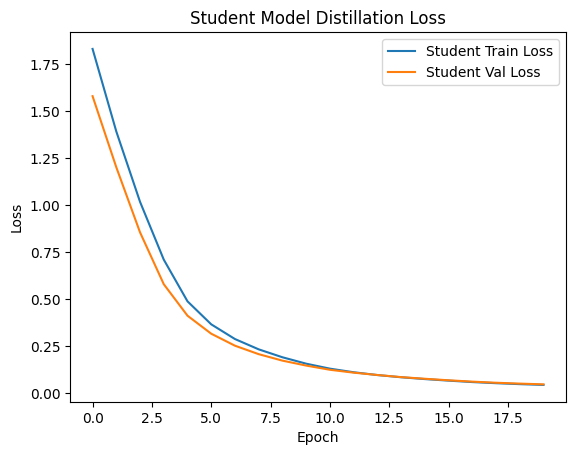

In [ ]:
import matplotlib.pyplot as plt

plt.plot(student_history.history['loss'], label='Student Train Loss')
plt.plot(student_history.history['val_loss'], label='Student Val Loss')
plt.legend()
plt.title("Student Model Distillation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


Train Suitability Gain Regression Model

In [ ]:
# ==========================================
# SUITABILITY GAIN MODEL (RF, Multi-label)
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MultiLabelBinarizer

# Features: decision features + multi-label actions
gain_features = decision_features + ["actions"]

# Drop rows missing features or suitability_gain
gain_df = df.dropna(subset=decision_features + ["actions", "suitability_gain"])

# Convert actions (list of labels) into binary columns
mlb = MultiLabelBinarizer(classes=all_actions)
actions_encoded = mlb.fit_transform(gain_df["actions"])
actions_df = pd.DataFrame(actions_encoded, columns=mlb.classes_, index=gain_df.index)

# Combine numeric features + encoded actions
X_gain = pd.concat([gain_df[decision_features], actions_df], axis=1)
y_gain = gain_df["suitability_gain"]

# Preprocessor: scale numeric features only
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), decision_features)
], remainder="passthrough")  # keep encoded actions as-is

# Random Forest pipeline
gain_model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
])

gain_model.fit(X_gain, y_gain)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['temperature', 'humidity',
                                                   'soil_moisture', 'ph', 'N',
                                                   'P', 'K', 'temp_mean',
                                                   'temp_var',
                                                   'humidity_mean_roll',
                                                   'np_ratio', 'nk_ratio',
                                                   'temperature_opt_min',
                                                   'temperature_opt_max',
                                                   'temperature_opt_mean',
                                                   'humidity_min',
                                                   'humidity_max',
                                                   'humidity_mean',
                                                   'ph_opt_min', 'ph_opt_max',
                                                   'ph_opt_mean',
                                                   'nitrogen_min',
                                                   'nitrogen_max',
                                                   'nitrogen_mean',
                                                   'phosphorus_min',
                                                   'phosphorus_max',
                                                   'phosphorus_mean',
                                                   'potassium_min',
                                                   'potassium_max',
                                                   'potassium_mean', ...])])),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
#Evaluation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred_gain = gain_model.predict(X_gain)

# Metrics
r2 = r2_score(y_gain, y_pred_gain)
mae = mean_absolute_error(y_gain, y_pred_gain)
rmse = np.sqrt(mean_squared_error(y_gain, y_pred_gain))

print("\n📊 Suitability Gain Model Evaluation")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Feature importance
rf = gain_model.named_steps["rf"]
importances = rf.feature_importances_

# Match importances to feature names
feature_names = gain_model.named_steps["prep"].get_feature_names_out()
importance_table = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)



📊 Suitability Gain Model Evaluation
R²:   0.9980
MAE:  0.4019
RMSE: 0.8116


In [ ]:
import numpy as np
from tabulate import tabulate

# Pick 10 random samples
indices = np.random.choice(len(df), size=10, replace=False)

rows = []
for i in indices:
    crop = df.iloc[i]["crop_id"]
    actions = df.iloc[i]["actions"]
    gain = df.iloc[i]["suitability_gain"]
    rows.append([i, crop, ", ".join(actions), gain])

headers = ["Row #", "Crop", "Actions", "Suitability Gain"]
print("\n🔎 Sample Suitability Gain Predictions (Rule-based Mapping):")
print(tabulate(rows, headers=headers, tablefmt="fancy_grid"))



🔎 Sample Suitability Gain Predictions (Rule-based Mapping):
╒═════════╤════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤════════════════════╕
│   Row # │   Crop │ Actions                                                                                                                              │   Suitability Gain │
╞═════════╪════════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪════════════════════╡
│    1324 │     21 │ Decrease pH, Add nitrogen fertilizer, Add phosphorus fertilizer, Add potassium fertilizer                                            │                 52 │
├─────────┼────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────────┤
│    1813 │      4 │ Increase irrigation, Add nitrogen

Save All Artifacts

In [ ]:
# ==========================================
# SAVE MODELS FOR DEPLOYMENT
# ==========================================

import os, joblib

# Create the artifacts directory if it doesn't exist
os.makedirs('artifacts', exist_ok=True)

# Save preprocessing artifacts
joblib.dump(scaler, "artifacts/decision_scaler.joblib")
joblib.dump(mlb, "artifacts/actions_mlb.joblib")   # <-- replaces care_le
joblib.dump(gain_model, "artifacts/gain_model.joblib")
joblib.dump(crop_le, "artifacts/crop_label_encoder.joblib")
joblib.dump(meta, "artifacts/meta.joblib")

# Save models
teacher_model.save("artifacts/teacher_model.h5")
student_model.save("artifacts/student_model_edge.h5")


Final Inference Function (Used by Raspberry Pi)

In [ ]:
# ==========================================
# BLOCK 10 — FINAL INFERENCE PIPELINE (Multi-label)
# ==========================================

def full_inference(reading_row, scaler, crop_le, student_model, gain_model, mlb):
    # Encode crop
    crop_id = crop_le.transform([reading_row['crop_name'].lower()])[0]
    reading_row['crop_id'] = crop_id

    # 1) Suitability (rule-based)
    suitability_score = compute_suitability_row(reading_row)

    # 2) Actions (student model, multi-label)
    X_dec = scaler.transform(np.array([reading_row[decision_features]]))
    probs = student_model.predict(X_dec, verbose=0)[0]

    threshold = 0.5
    pred_actions = [mlb.classes_[j] for j in range(len(mlb.classes_)) if probs[j] > threshold]
    confidences = {mlb.classes_[j]: float(probs[j]) for j in range(len(mlb.classes_)) if probs[j] > threshold}

    # 3) Expected gain (multi-label input)
    gain_input = reading_row.copy()
    gain_input["actions"] = pred_actions
    gain_pred = gain_model.predict(pd.DataFrame([gain_input]))[0]

    new_suitability = min(100, suitability_score + gain_pred)

    return {
        "crop": reading_row['crop_name'],
        "suitability_now": round(suitability_score, 2),
        "recommended_actions": pred_actions,
        "expected_gain": round(gain_pred, 2),
        "suitability_after_actions": round(new_suitability, 2),
        "model_confidences": {a: round(c*100, 2) for a, c in confidences.items()}
    }


In [ ]:
import tensorflow as tf

# Load the trained student model (no need for custom_objects if not retraining)
model = tf.keras.models.load_model('artifacts/student_model_edge.h5', compile=False)

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open('artifacts/student_model_edge.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpvctnxsln'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 43), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134549251028176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134547987069840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134547987062544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134547987068880: TensorSpec(shape=(), dtype=tf.resource, name=None)
